# Hotdog / Not Hotdog — Project 1

**Intro to Deep Learning in Computer Vision (02516)**

Recreating Jian-Yang's hotdog / not-hotdog classifier from *Silicon Valley*: a CNN that
sorts images into two classes.

## How this project is organised

| File | What's in it |
|---|---|
| `hotdog.py` | All the reusable code: data loading, models, the training loop, saliency. Open it — it's commented. |
| this notebook | The story: run each experiment, look at the results, decide what to do next. |
| `results/` | One JSON per training run (accuracy per epoch). |
| `checkpoints/` | The best weights from each run. |
| `figures/` | PNGs, ready to paste into the report. |

Because every run writes to `results/` and `checkpoints/`, **you never have to retrain a
model just to redraw a figure**. If the kernel dies, your results survive.

## How the experiments are structured

Each section below answers one of the questions in the project PDF, and each one is the
same recipe: change *one* thing, retrain, compare. That's what makes the comparison
mean something — if you change two things at once you can't tell which one helped.

> **The one rule that matters:** the test set is used **once**, at the very end.
> Every decision along the way is made on the *validation* set. Picking your model by
> test accuracy makes the number you report too optimistic.

In [6]:
import torch
import pandas as pd

import hotdog                                 # our helper module (hotdog.py, next to this notebook)
import importlib; importlib.reload(hotdog)    # re-run this cell after you edit hotdog.py

# How long each experiment trains. Turn these down for a quick pass,
# up if you have time and want cleaner curves.
EPOCHS = 12          # small CNN experiments (~15 s/epoch on CPU)
RESNET_EPOCHS = 6    # ResNet is slower per epoch but converges much faster

device = hotdog.get_device()
print("training on:", device)

training on: cpu


---
# 1. The data

2047 training images and 1862 test images, from the ImageNet categories *pets, furniture,
people, food, frankfurter, chili-dog, hotdog*. They come at all sorts of resolutions, so
they're all resized to 128×128 — a forward pass needs every image the same size.

Two things happen in `get_loaders` that are worth knowing about:

**Images are decoded once and kept in RAM.** JPEG decoding was taking ~19 s per epoch,
and it produces identical pixels every time. Decoding once into a `uint8` tensor (~100 MB)
roughly halves the epoch time.

**The training set is split 80/20 into train and validation.** The test set stays sealed
until the very end. The split is seeded, so it's identical in every experiment and the
comparisons are fair.

In [7]:
train_loader, val_loader, test_loader = hotdog.get_loaders(
    data_path="hotdog_nothotdog",
    size=128,
    batch_size=64,
    augment=False,      # start without augmentation; we add it in section 4
    val_fraction=0.2,
)

n = lambda loader: len(loader.dataset)
print(f"train: {n(train_loader):5d} images")
print(f"val:   {n(val_loader):5d} images   (used to make every decision)")
print(f"test:  {n(test_loader):5d} images   (used ONCE, at the end)")
print("classes:", hotdog.CLASS_NAMES, "-> labels 0 and 1")

loading train:   0%|          | 0/2047 [00:00<?, ?it/s]

loading test:   0%|          | 0/1862 [00:00<?, ?it/s]

train:  1638 images
val:     409 images   (used to make every decision)
test:   1862 images   (used ONCE, at the end)
classes: ['hotdog', 'not hotdog'] -> labels 0 and 1


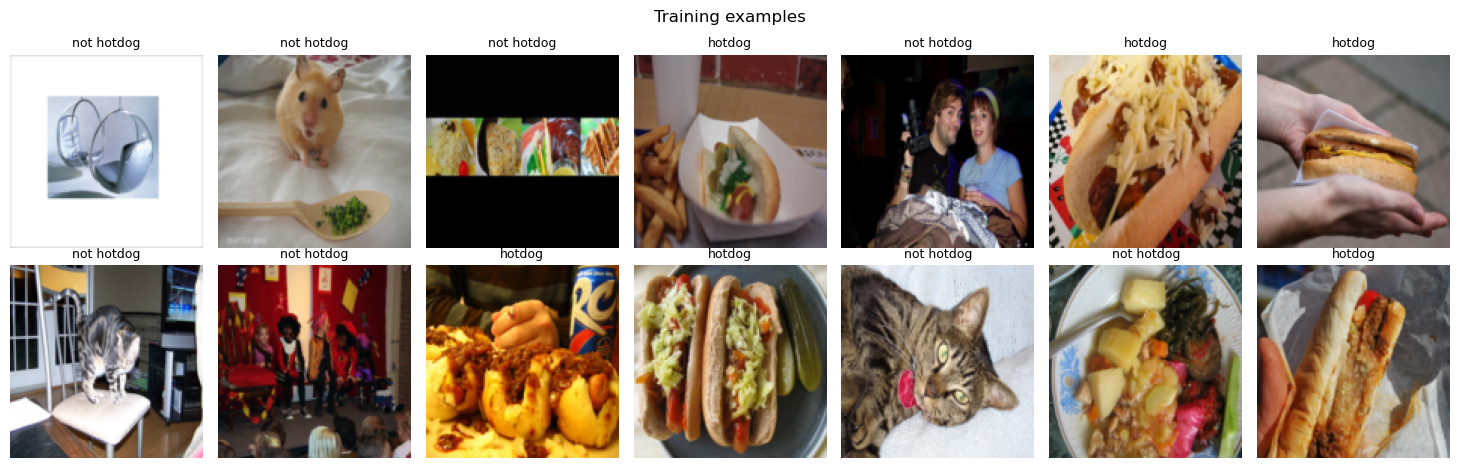

In [8]:
# A look at what we're actually working with.
images, labels = next(iter(train_loader))
hotdog.show_images(images[:14],
                   [hotdog.CLASS_NAMES[i] for i in labels[:14]],
                   filename="fig1_data_examples.png",
                   title="Training examples");

---
# 2. A baseline to beat

Start with the simplest thing that could work, then improve it one step at a time. A
baseline is what makes every later number meaningful — "83%" means nothing on its own,
"83% vs the 74% baseline" is a result.

The architecture is four blocks of **Conv 3×3 → ReLU → MaxPool**, with the channel count
doubling each block (16 → 32 → 64 → 128) as the image shrinks (128 → 64 → 32 → 16 → 8).
That "smaller but deeper" shape is the standard CNN design: trade spatial detail for a
richer description of *what* is in the image.

No batch norm, no augmentation, no dropout yet — those are the experiments.

*For the report: this is where you say what you started with and why.*

In [9]:
baseline = hotdog.make_cnn(n_blocks=4, width=16, batch_norm=False, dropout=0.0)
print("trainable parameters:", hotdog.count_parameters(baseline))

h_baseline = hotdog.train_model(
    baseline, train_loader, val_loader,
    name="1_baseline",
    epochs=EPOCHS,
    optimizer="adam", lr=1e-3,
)

trainable parameters: 97698


epoch 1/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch  1/12  train loss 0.672 acc 0.588   |   val loss 0.628 acc 0.653  <-- best


epoch 2/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch  2/12  train loss 0.635 acc 0.662   |   val loss 0.609 acc 0.682  <-- best


...

  epoch 10/12  train loss 0.502 acc 0.767   |   val loss 0.485 acc 0.800  <-- best


epoch 11/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch 11/12  train loss 0.497 acc 0.777   |   val loss 0.460 acc 0.800  <-- best


epoch 12/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch 12/12  train loss 0.461 acc 0.784   |   val loss 0.438 acc 0.800  <-- best
  done in 3.1 min. best val acc = 0.800  (saved as '1_baseline')


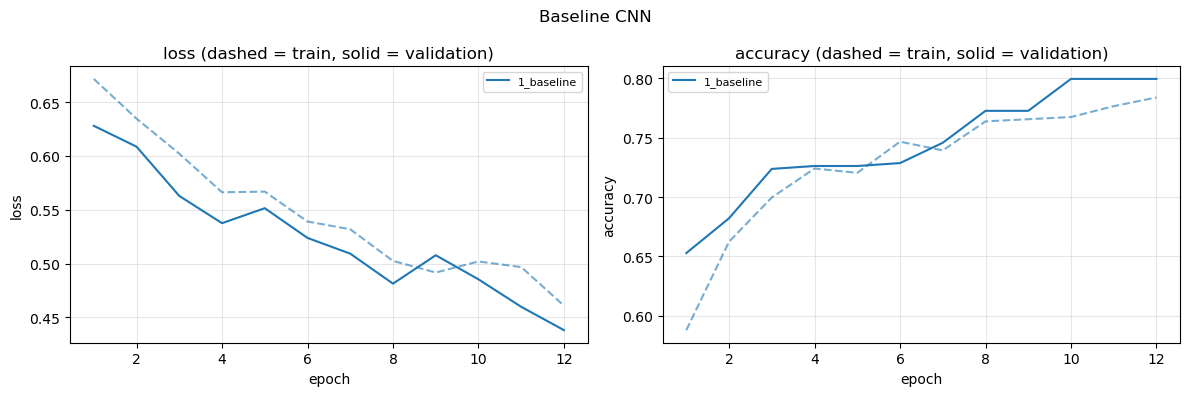

In [10]:
hotdog.plot_curves("1_baseline", title="Baseline CNN", filename="fig2_baseline.png");

**How to read those curves** — this is most of the analysis in your report:

| What you see | What it means | What to do |
|---|---|---|
| Train accuracy climbs, validation flattens or falls | Overfitting — memorising the training images | Augmentation, dropout, fewer parameters |
| Both stay low and flat | Underfitting, or the learning rate is too low | Bigger model, higher lr, train longer |
| Validation curve jumps around wildly | Learning rate too high | Lower the lr |

---
# 3. Does batch normalisation help?

Batch norm renormalises each channel using the mean and variance of the current batch.
It keeps the signal flowing through the network at a stable scale, which usually means
faster, more stable training and tolerance for a higher learning rate.

**One change only:** identical architecture, identical optimizer, `batch_norm=True`.

In [11]:
bn_model = hotdog.make_cnn(n_blocks=4, width=16, batch_norm=True)

h_bn = hotdog.train_model(
    bn_model, train_loader, val_loader,
    name="2_batchnorm",
    epochs=EPOCHS,
    optimizer="adam", lr=1e-3,
)

epoch 1/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch  1/12  train loss 0.604 acc 0.683   |   val loss 0.585 acc 0.704  <-- best


epoch 2/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch  2/12  train loss 0.513 acc 0.760   |   val loss 0.625 acc 0.655


epoch 3/12:   0%|          | 0/26 [00:00<?, ?it/s]

...

  epoch 10/12  train loss 0.390 acc 0.833   |   val loss 0.439 acc 0.814  <-- best


epoch 11/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch 11/12  train loss 0.362 acc 0.848   |   val loss 0.448 acc 0.814  <-- best


epoch 12/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch 12/12  train loss 0.349 acc 0.846   |   val loss 0.433 acc 0.802
  done in 3.5 min. best val acc = 0.814  (saved as '2_batchnorm')


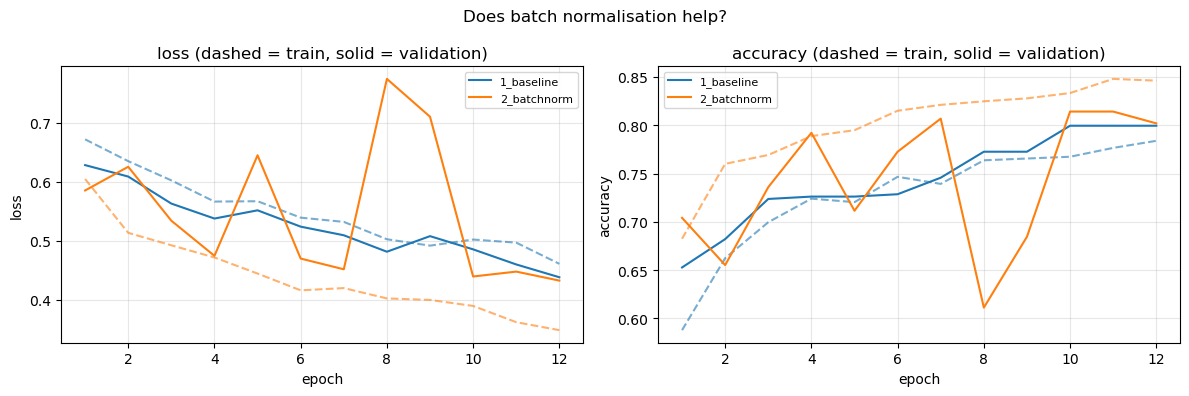

In [12]:
hotdog.plot_curves(["1_baseline", "2_batchnorm"],
                   title="Does batch normalisation help?",
                   filename="fig3_batchnorm.png");

---
# 4. Which optimizer?

Three optimizers, same model, same number of epochs:

- **SGD** — take a step straight downhill. Simple, but slow in narrow valleys.
- **SGD + momentum** — keep some of the previous step, like a ball rolling downhill.
  Smooths out the zig-zagging and usually converges faster.
- **Adam** — adapts the step size per parameter. Usually the fastest to a decent result
  with the least tuning, which is why it's the default choice here.

Note the **different learning rates**: plain SGD needs a much larger one (1e-2) than Adam
(1e-3), because Adam effectively rescales each parameter's step internally. Comparing
optimizers at the same lr would be an unfair test that just says "1e-3 is bad for SGD".

Adam was already run above as `2_batchnorm`, so we only need the other two.

In [13]:
for opt_name, lr in [("sgd", 1e-2), ("momentum", 1e-2)]:
    model = hotdog.make_cnn(n_blocks=4, width=16, batch_norm=True)
    hotdog.train_model(
        model, train_loader, val_loader,
        name=f"3_{opt_name}",
        epochs=EPOCHS,
        optimizer=opt_name, lr=lr,
    )

epoch 1/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch  1/12  train loss 0.666 acc 0.606   |   val loss 0.624 acc 0.699  <-- best


epoch 2/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch  2/12  train loss 0.599 acc 0.689   |   val loss 0.569 acc 0.689


epoch 3/12:   0%|          | 0/26 [00:00<?, ?it/s]

...

  epoch 10/12  train loss 0.410 acc 0.821   |   val loss 0.481 acc 0.780  <-- best


epoch 11/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch 11/12  train loss 0.390 acc 0.833   |   val loss 0.549 acc 0.768


epoch 12/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch 12/12  train loss 0.384 acc 0.820   |   val loss 0.503 acc 0.802  <-- best
  done in 3.0 min. best val acc = 0.802  (saved as '3_momentum')


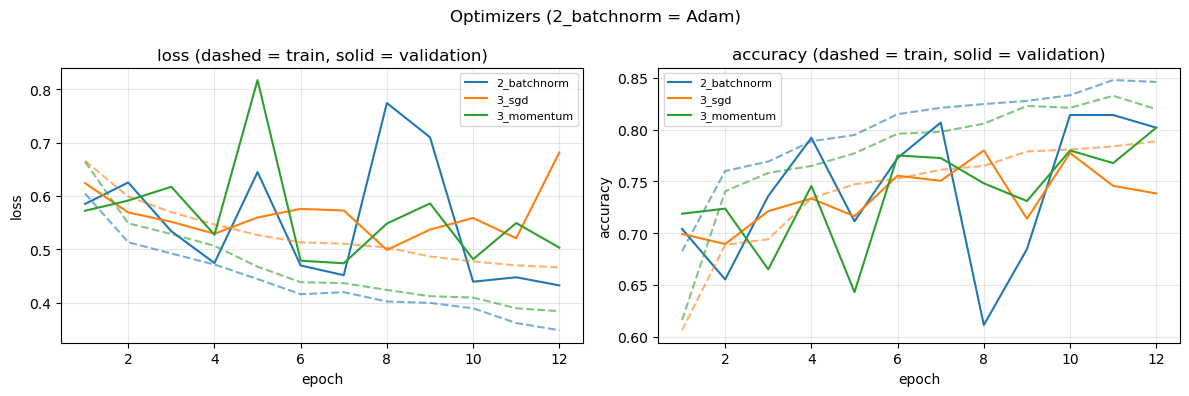

In [14]:
hotdog.plot_curves(["2_batchnorm", "3_sgd", "3_momentum"],
                   title="Optimizers (2_batchnorm = Adam)",
                   filename="fig4_optimizers.png");

---
# 5. Does data augmentation help?

With only ~1600 training images, the network can simply memorise them. Augmentation
makes a fresh, slightly different version of each image every epoch, so memorising stops
working and the model has to learn something more general.

What we apply (see `_make_transform` in `hotdog.py`):

- **Horizontal flip** — a mirrored hotdog is still a hotdog.
- **Random resized crop** — teaches the model that position and scale vary.
- **Colour jitter** — robustness to lighting.

Note we do **not** flip vertically: upside-down food is not something the test set
contains, so it would just make the task harder for no benefit. Augmentation should
reflect variation you actually expect to see.

Augmentation is applied to training data only — validation and test must stay fixed,
otherwise the numbers you compare would be noisy for the wrong reason.

> Augmented models often need **more** epochs, since each epoch is a harder problem.
> If the augmented curve is still climbing at the end, raise `EPOCHS` and rerun.

In [15]:
# Rebuild the loaders with augmentation switched on.
# (The images are already cached in RAM, so this is instant.)
aug_train_loader, val_loader, test_loader = hotdog.get_loaders(augment=True)

model = hotdog.make_cnn(n_blocks=4, width=16, batch_norm=True)
hotdog.train_model(
    model, aug_train_loader, val_loader,
    name="4_augmented",
    epochs=EPOCHS,
    optimizer="adam", lr=1e-3,
)

epoch 1/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch  1/12  train loss 0.619 acc 0.669   |   val loss 0.550 acc 0.738  <-- best


epoch 2/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch  2/12  train loss 0.531 acc 0.753   |   val loss 0.537 acc 0.746  <-- best


epoch 3/12:   0%|          | 0/26 [00:00<?, ?it/s]

...

epoch 11/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch 11/12  train loss 0.421 acc 0.805   |   val loss 0.460 acc 0.819  <-- best


epoch 12/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch 12/12  train loss 0.415 acc 0.804   |   val loss 0.478 acc 0.787
  done in 2.7 min. best val acc = 0.819  (saved as '4_augmented')


{'name': '4_augmented',
 'epochs': 12,
 'optimizer': 'adam',
 'lr': 0.001,
 'weight_decay': 0.0,
 'n_params': 98178,
 'train_loss': [0.6190525906135457,
  0.5306438012583061,
  0.5040678927386054,
  0.4934619567624233,
  0.49138294708015573,
  0.47346593295843753,
  0.45394100934740095,
  0.4550792676770789,
  0.4502942514434111,
  0.43151151817360206,
  0.42149594669959195,
  0.41457533974641697],
 'train_acc': [0.6691086691086691,
  0.7533577533577533,
  0.7667887667887668,
  0.7606837606837606,
  0.7619047619047619,
  0.7826617826617827,
  0.7936507936507936,
  0.7814407814407814,
  0.7948717948717948,
  0.8058608058608059,
  0.8046398046398047,
  0.8040293040293041],
 'val_loss': [0.5501329449977734,
  0.5368469863182758,
  0.6409439306095934,
  0.5132451745292085,
  0.5344668647187846,
  0.49975743095565833,
  0.5427910587898385,
  0.4812507885883956,
  0.4575798249186397,
  0.42271721333921103,
  0.460377873884728,
  0.4777730554706601],
 'val_acc': [0.738386332988739,
  0.745721

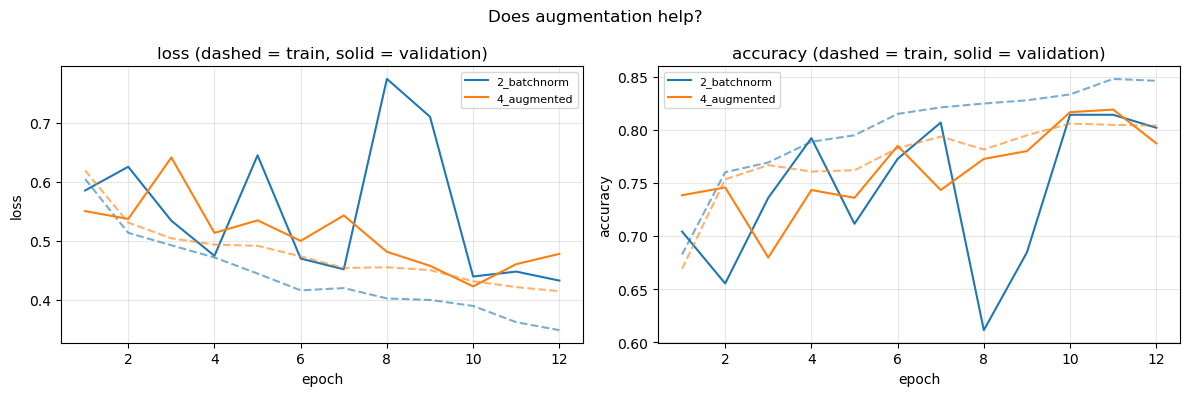

In [16]:
hotdog.plot_curves(["2_batchnorm", "4_augmented"],
                   title="Does augmentation help?",
                   filename="fig5_augmentation.png");

---
# 6. Iterating on the architecture

Now that the training setup is settled (batch norm + Adam + augmentation), change the
*shape* of the network and see what it's worth:

- **wider** — twice the channels, so more patterns per layer
- **deeper + dropout** — one more block, plus dropout to counter the extra capacity

*For the report: this is the "how did you decide on your architecture, did you start with
something else" question. The answer is this sequence of experiments.*

In [17]:
variants = {
    "5_wider":           dict(n_blocks=4, width=32, dropout=0.0),
    "5_deeper_dropout":  dict(n_blocks=5, width=16, dropout=0.3),
}

for name, kwargs in variants.items():
    model = hotdog.make_cnn(batch_norm=True, **kwargs)
    print(f"\n{name}  ({hotdog.count_parameters(model)} parameters)")
    hotdog.train_model(
        model, aug_train_loader, val_loader,
        name=name, epochs=EPOCHS, optimizer="adam", lr=1e-3,
    )


5_wider  (389890 parameters)


epoch 1/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch  1/12  train loss 0.638 acc 0.652   |   val loss 0.546 acc 0.731  <-- best


epoch 2/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch  2/12  train loss 0.532 acc 0.743   |   val loss 0.610 acc 0.707


...

  epoch 10/12  train loss 0.414 acc 0.820   |   val loss 0.398 acc 0.824  <-- best


epoch 11/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch 11/12  train loss 0.389 acc 0.822   |   val loss 0.384 acc 0.812


epoch 12/12:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch 12/12  train loss 0.387 acc 0.828   |   val loss 0.384 acc 0.809
  done in 2.8 min. best val acc = 0.824  (saved as '5_deeper_dropout')


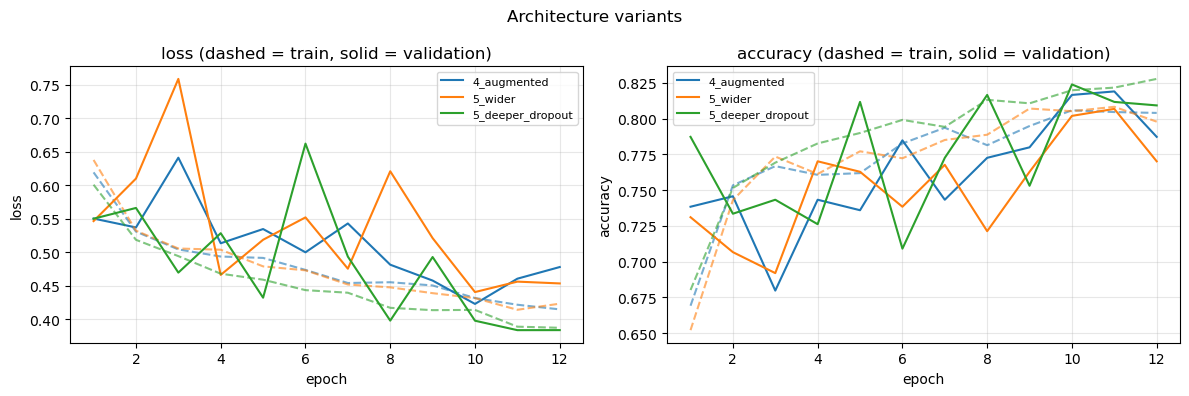

In [18]:
hotdog.plot_curves(["4_augmented", "5_wider", "5_deeper_dropout"],
                   title="Architecture variants",
                   filename="fig6_architecture.png");

---
# 7. Transfer learning

A ResNet18 trained on ImageNet's 1.2 million images has already learned generic visual
features — edges, textures, materials, shapes. Reusing them should beat learning from
scratch on our ~1600 images.

Three runs, which together make the argument properly:

| Run | What it does | Why it's here |
|---|---|---|
| `6_resnet_frozen` | Freeze everything, train only the new 2-class layer | ResNet as a fixed feature extractor. Fast, hard to overfit. |
| `6_resnet_finetune` | Train the whole network, small lr | Lets the features adapt to hotdogs |
| `6_resnet_scratch` | Same architecture, random init | **The honest comparison.** Without this you can't tell whether ResNet won because of the *pretrained weights* or just because it's a bigger network. |

Fine-tuning uses **lr = 1e-4**, ten times smaller than usual. The pretrained weights are
already good; a large learning rate would wash them out in the first few batches, which
throws away the very thing we came for.

In [19]:
resnet_runs = {
    "6_resnet_frozen":   dict(pretrained=True,  freeze=True,  lr=1e-3),
    "6_resnet_finetune": dict(pretrained=True,  freeze=False, lr=1e-4),
    "6_resnet_scratch":  dict(pretrained=False, freeze=False, lr=1e-4),
}

for name, cfg in resnet_runs.items():
    model = hotdog.make_resnet18(pretrained=cfg["pretrained"], freeze=cfg["freeze"])
    print(f"\n{name}  ({hotdog.count_parameters(model)} trainable parameters)")
    hotdog.train_model(
        model, aug_train_loader, val_loader,
        name=name, epochs=RESNET_EPOCHS, optimizer="adam", lr=cfg["lr"],
    )


6_resnet_frozen  (1026 trainable parameters)


epoch 1/6:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch  1/6  train loss 0.555 acc 0.711   |   val loss 0.372 acc 0.851  <-- best


epoch 2/6:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch  2/6  train loss 0.362 acc 0.852   |   val loss 0.287 acc 0.885  <-- best


...

  epoch  4/6  train loss 0.454 acc 0.788   |   val loss 0.487 acc 0.763  <-- best


epoch 5/6:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch  5/6  train loss 0.439 acc 0.795   |   val loss 0.470 acc 0.790  <-- best


epoch 6/6:   0%|          | 0/26 [00:00<?, ?it/s]

  epoch  6/6  train loss 0.427 acc 0.805   |   val loss 0.460 acc 0.787
  done in 4.0 min. best val acc = 0.790  (saved as '6_resnet_scratch')


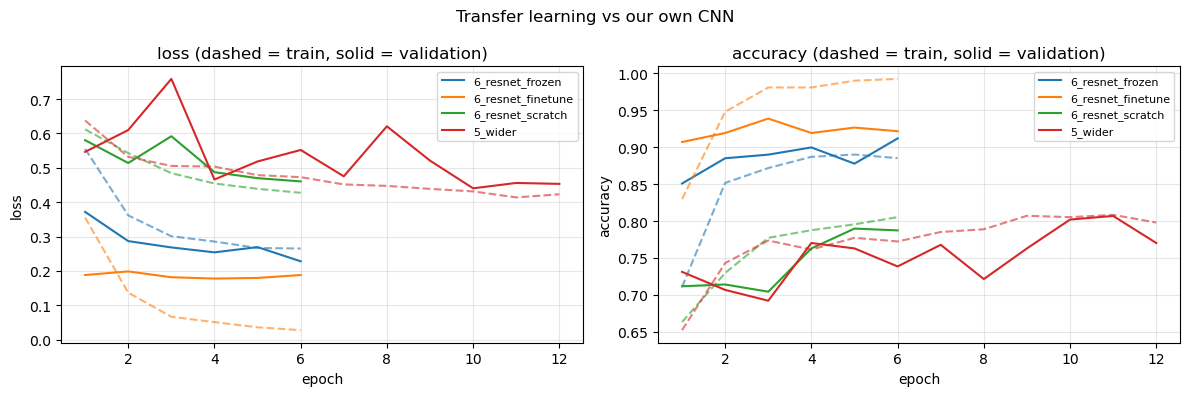

In [20]:
hotdog.plot_curves(list(resnet_runs) + ["5_wider"],
                   title="Transfer learning vs our own CNN",
                   filename="fig7_transfer.png");

---
# 8. All results

Everything trained so far, read back from `results/`. **This table goes in the report.**

It survives a kernel restart, and it doesn't care what order you ran the experiments in.

In [21]:
results = hotdog.load_results()
results

,run,best val acc,final train acc,optimizer,lr,params,epochs,minutes
7,6_resnet_finetune,0.9389,0.9927,adam,0.0001,11177538,6,4.0
8,6_resnet_frozen,0.9120,0.8852,adam,0.0010,1026,6,1.9
5,5_deeper_dropout,0.8240,0.8278,adam,0.0010,394114,12,2.8
4,4_augmented,0.8191,0.8040,adam,0.0010,98178,12,2.7
1,2_batchnorm,0.8142,0.8462,adam,0.0010,98178,12,3.5
6,5_wider,0.8068,0.7979,adam,0.0010,389890,12,5.4
2,3_momentum,0.8020,0.8199,momentum,0.0100,98178,12,3.0
0,1_baseline,0.7995,0.7839,adam,0.0010,97698,12,3.1
9,6_resnet_scratch,0.7897,0.8053,adam,0.0001,11177538,6,4.0
3,3_sgd,0.7800,0.7888,sgd,0.0100,98178,12,3.8


A large gap between *final train acc* and *best val acc* means that run was overfitting.
Compare that gap across the augmented and non-augmented runs — that's the clearest
evidence for whether augmentation did its job.

---
# 9. Final evaluation on the test set

**This is the one time the test set gets used.** Pick the winner from the table above by
its *validation* accuracy, then report its test accuracy.

Set `BEST_RUN` to the top row of the table, and build the matching architecture — the
saved weights only load into the network they came from.

In [22]:
BEST_RUN = "6_resnet_finetune"     # <-- set this to the best row in the table above

# Rebuild the same architecture the run used, then load its best saved weights.
if BEST_RUN.startswith("6_resnet"):
    best_model = hotdog.make_resnet18(pretrained=False)   # weights come from the checkpoint
elif BEST_RUN == "5_wider":
    best_model = hotdog.make_cnn(n_blocks=4, width=32, batch_norm=True)
elif BEST_RUN == "5_deeper_dropout":
    best_model = hotdog.make_cnn(n_blocks=5, width=16, batch_norm=True, dropout=0.3)
else:
    best_model = hotdog.make_cnn(n_blocks=4, width=16, batch_norm=True)

hotdog.load_best(best_model, BEST_RUN)

test = hotdog.evaluate(best_model, test_loader)
print(f"run:           {BEST_RUN}")
print(f"TEST accuracy: {test['acc']:.4f}   ({int(test['acc'] * len(test['labels']))} / {len(test['labels'])} correct)")
print(f"test loss:     {test['loss']:.4f}")

run:           6_resnet_finetune
TEST accuracy: 0.9039   (1683 / 1862 correct)
test loss:     0.2549


In [23]:
# Confusion matrix: which class gets confused with which.
pd.crosstab(
    pd.Series([hotdog.CLASS_NAMES[i] for i in test["labels"]], name="true"),
    pd.Series([hotdog.CLASS_NAMES[i] for i in test["preds"]], name="predicted"),
)

predicted,hotdog,not hotdog
true,,
hotdog,785,110
not hotdog,69,898


---
# 10. Which images does it get wrong?

The PDF asks *which* test images are misclassified and whether there's an obvious reason.

Below are the mistakes the model was **most confident** about. Those are the informative
ones: a 51% wrong answer is just an ambiguous picture, but a 99% wrong answer tells you
what the model has actually latched onto.

Things worth looking for, and writing about:

- Sandwiches, subs, baguettes — anything bun-shaped
- Non-hotdog food that's red and yellow, like ketchup and mustard
- Hotdogs that are tiny, or half out of frame, or one of many objects on a table
- Cartoons and drawings of hotdogs

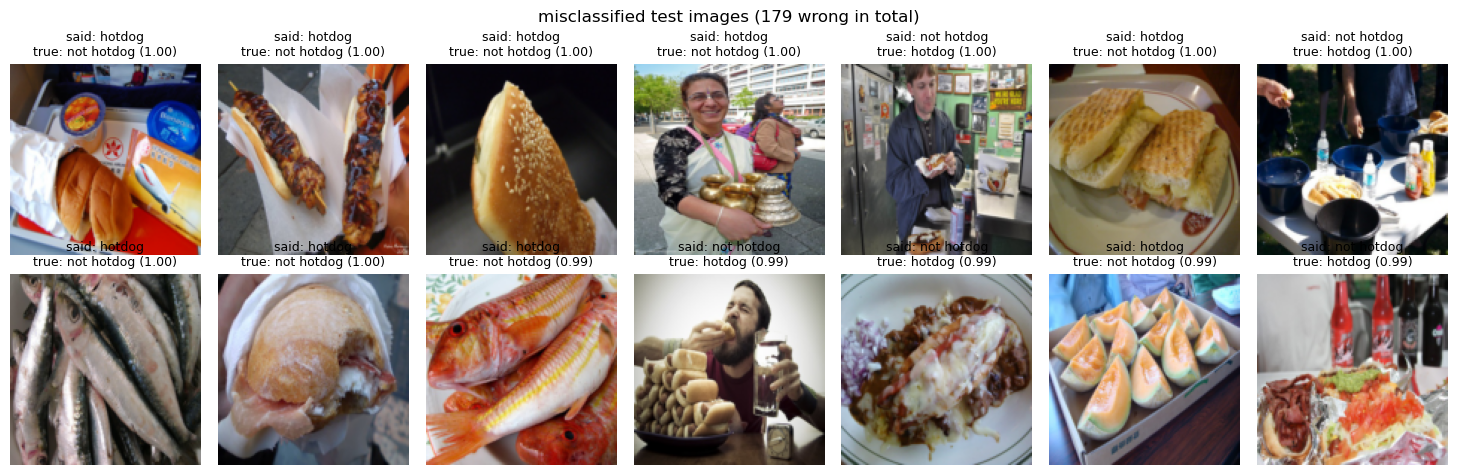

In [24]:
hotdog.show_mistakes(best_model, test_loader, n=14,
                     most_confident=True,
                     filename="fig8_mistakes.png");

---
# 11. Saliency maps

**The question a saliency map answers:** which pixels is the model actually using?

Normally backprop computes the gradient of the loss with respect to the *weights*. For a
saliency map we keep the weights fixed and compute the gradient of the class score with
respect to the *input pixels* instead. A large gradient at a pixel means changing that
pixel would move the score a lot — so the model is relying on it.

We take the absolute value (influence matters, direction doesn't) and the maximum over
the three colour channels, which gives one heat map per image.

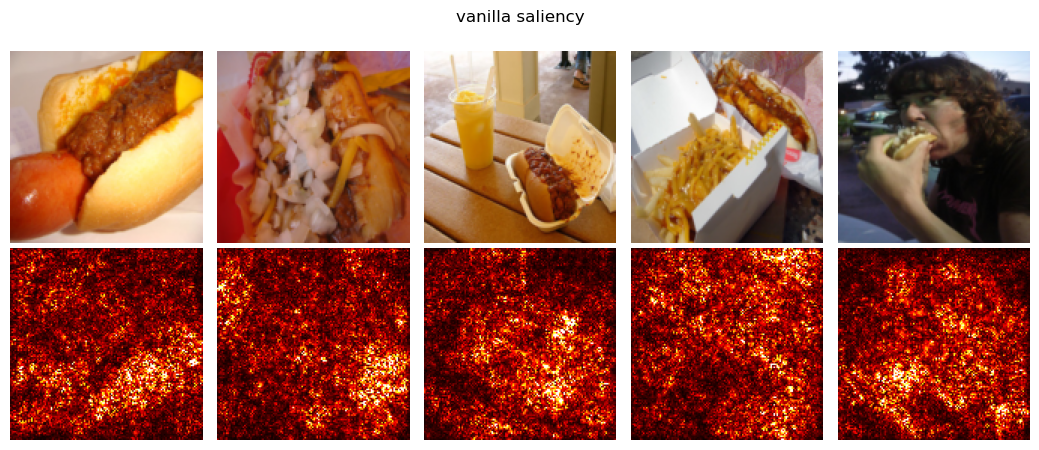

In [25]:
# Take some test hotdogs to explain. The test loader isn't shuffled and the
# files are sorted, so the first batch is the hotdog class.
test_images, test_labels = next(iter(test_loader))
examples = test_images[(test_labels == 0).nonzero().squeeze(1)[:5]]

hotdog.show_saliency(best_model, examples, use_smoothgrad=False,
                     filename="fig9_saliency_vanilla.png");

## SmoothGrad

The map above is speckly. That's not a bug — the gradient of a deep network genuinely
fluctuates sharply from pixel to pixel, because the function has many tiny local wiggles.
SmoothGrad (Smilkov et al., 2017) fixes this by adding Gaussian noise to the image many
times and averaging the resulting saliency maps.

### Why adding Gaussian noise = sampling from a normal distribution centred at the image

*(the PDF explicitly asks you to be able to explain this — here it is)*

Take the image as a fixed vector $x$, and draw noise $\varepsilon \sim \mathcal{N}(0, \sigma^2 I)$.
Form the noisy image

$$x' = x + \varepsilon.$$

Adding a **constant** to a normally distributed random variable shifts its mean and
leaves its variance unchanged. Since $x$ is fixed and $\varepsilon$ has mean $0$ and
covariance $\sigma^2 I$:

$$\mathbb{E}[x'] = x + \mathbb{E}[\varepsilon] = x, \qquad
\operatorname{Cov}(x') = \operatorname{Cov}(\varepsilon) = \sigma^2 I$$

and because a shifted Gaussian is still Gaussian,

$$x' \sim \mathcal{N}(x,\, \sigma^2 I).$$

So each noisy copy **is** a sample from a normal distribution centred on the original
image. SmoothGrad is therefore a Monte-Carlo estimate of the *average* saliency in a
neighbourhood of $x$:

$$\hat{M}(x) = \frac{1}{n}\sum_{i=1}^{n} M(x + \varepsilon_i) \;\approx\;
\mathbb{E}_{x' \sim \mathcal{N}(x, \sigma^2 I)}\big[M(x')\big]$$

rather than the saliency at the single point $x$. Averaging over that neighbourhood
cancels the local wiggles and leaves the structure the model consistently responds to.

$\sigma$ controls how wide the neighbourhood is, and it's a hyperparameter — the sweep
below shows what it does.

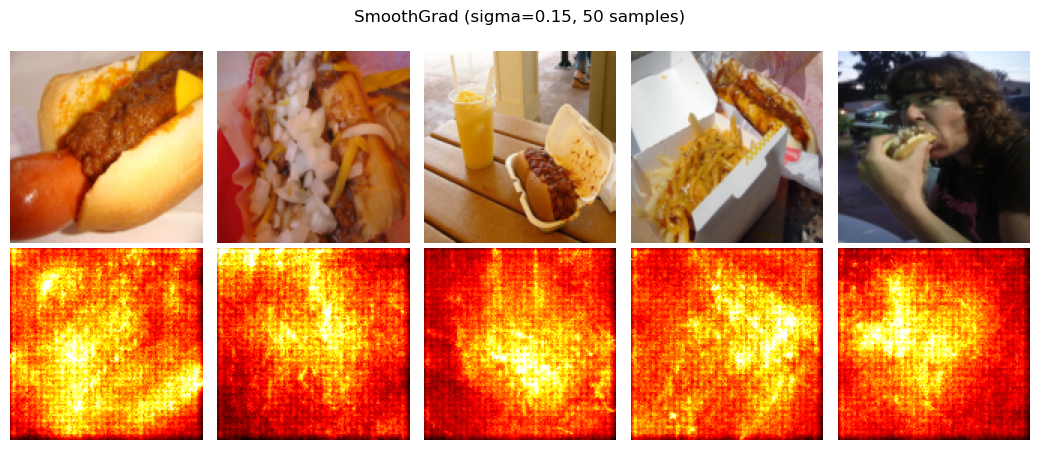

In [26]:
hotdog.show_saliency(best_model, examples, use_smoothgrad=True,
                     noise_level=0.15, n_samples=50,
                     filename="fig10_smoothgrad.png");

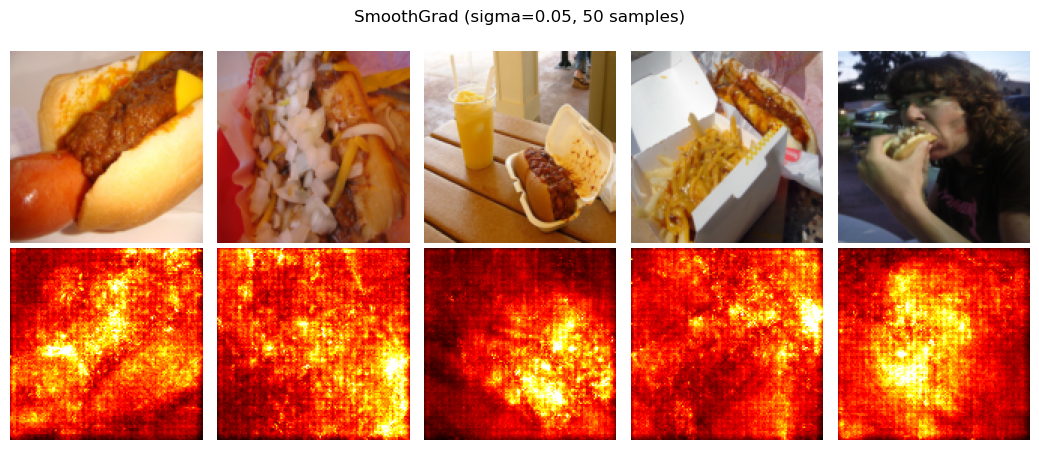

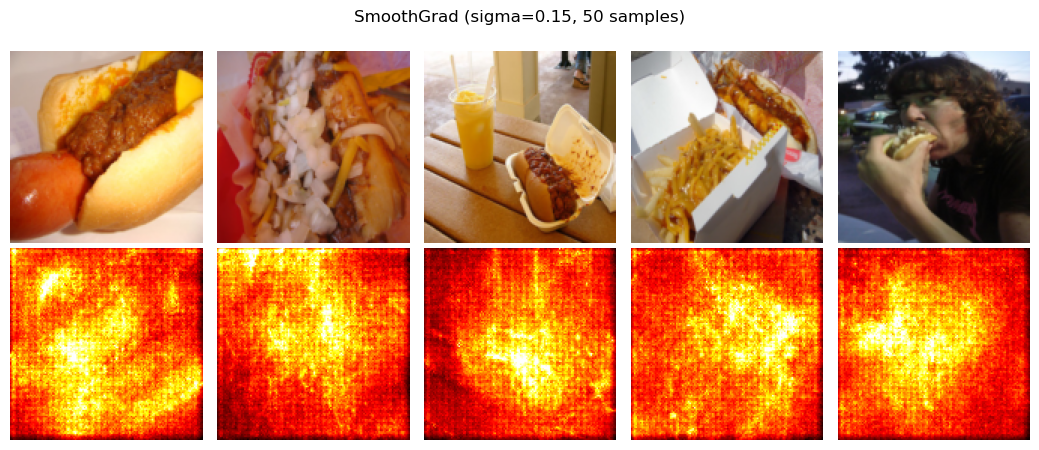

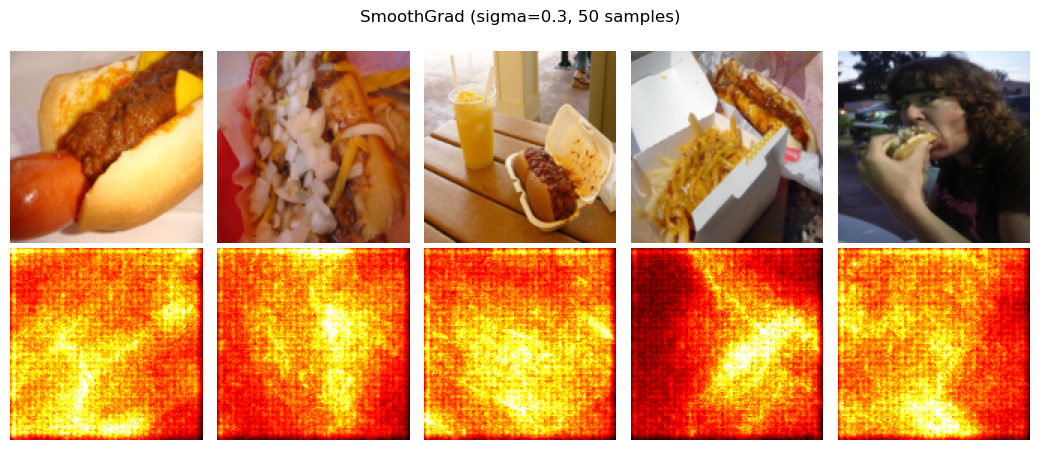

In [27]:
# Sweep sigma. Too small -> the noisy original map back.
#            Too large -> real detail blurred away.
for noise in [0.05, 0.15, 0.30]:
    hotdog.show_saliency(best_model, examples, use_smoothgrad=True,
                         noise_level=noise, n_samples=50,
                         filename=f"fig11_smoothgrad_sigma_{noise}.png")

**What to write about these:** do the maps land on the hotdog itself? If they light up
the plate, the background or the person holding it instead, the model has found a
shortcut — that's a genuine finding and worth reporting, especially alongside the
confident mistakes in section 10.

---
# 12. Use of generative AI

The PDF asks for a paragraph on this if you used AI tools. **Rewrite the draft below so
it's accurate for what you actually did** — don't hand in someone else's description.

> *Draft, edit before handing in:*
>
> We used Claude (Anthropic) throughout the project. It was used to debug the
> environment setup — in particular a crash caused by two copies of the Intel OpenMP
> runtime being loaded by PyTorch and conda's MKL, which killed the Jupyter kernel with
> no Python traceback — and to structure the code into a reusable module so that each
> experiment differed by a single argument. It was also used to draft explanatory text
> and to check our derivation of why adding Gaussian noise to an image is equivalent to
> sampling from a normal distribution centred on it. All experiments were run by us, and
> we verified the results and conclusions ourselves.

Be specific about what it did and didn't do — that's what the question is asking for.

---
# 13. Report checklist

Every question from the project PDF, and where its evidence lives:

- [ ] **How did you decide on your architecture? Did you start with something else?** → §2, §3, §6
- [ ] **How did you train it? Which optimizer? Did you compare optimizers?** → §4, fig4
- [ ] **Did you use data augmentation? Did it improve performance?** → §5, fig5
- [ ] **Did you use batch normalization? Does it help?** → §3, fig3
- [ ] **What is the accuracy? Which test images are wrong, and why?** → §9, §10, fig8
- [ ] **Did you use transfer learning? Does it help?** → §7, fig7
- [ ] **Saliency maps for some hotdog images** → §11, fig9
- [ ] **SmoothGrad, plus the Gaussian-noise explanation** → §11, fig10, fig11
- [ ] **Paragraph on generative AI use** → §12

All figures are in `figures/`, and the results table is section 8.

**One thing to confirm with the course:** the notebook's original header called this "the
poster hand-in project", while the PDF says "a PDF report to be uploaded on DTU Learn".
Those want very different amounts of text — check which one you're actually handing in.